# BSE Sensex 5-Day-Ahead Forecasting Pipeline (v5, 5-day horizon)

**Changes from the 1-day-ahead v5 pipeline (this is the same pipeline, retargeted):**

1. **`HORIZON` changed from 1 to 5.** Every model now predicts the close price
   5 trading days ahead (roughly one trading week) of the feature window,
   instead of the next day. This flows through `make_windows()` (target becomes
   `close[i+5]`), the deep-model training targets (`y_ret` is now the 5-day-ahead
   return), and the Diebold-Mariano test (`h=HORIZON=5`, which widens the
   autocorrelation correction further than at horizon 1 or 3).
2. **ARIMA walk-forward, same fix as the 3-day version.** The 1-day version got
   away with forecasting `steps=1` and using that directly, because with
   `HORIZON=1` the "next observed close" and "the target" are the same thing one
   step later. That coincidence breaks at multi-day horizons: the function
   forecasts `steps=HORIZON` ahead and takes the **last** step of that forecast
   as the prediction for the 5-day-ahead target, while still walking the model
   forward one actual observed day at a time (see `arima_walk_forward_predict`
   below).
3. **Trading-simulation caveat (read before writing the paper):** the
   simulation still takes one position per row using that row's 5-day-ahead
   prediction and evaluates it against the actual price 5 days later, but
   consecutive rows are only 1 trading day apart. This means the "5-day return"
   windows used for consecutive rows **overlap by 4 days** - even more overlap
   than the 3-day version had. Cumulative return, Sharpe, and max-drawdown as
   computed here should be read as "return from holding a fresh 5-day view every
   day," not as a non-overlapping trading strategy - report it that way, don't
   imply the equity curve reflects independent, compounding 5-day bets.
4. **Expect a bigger MDA/trading-vs-MAE gap than at horizon 1 or 3.** A full
   trading week out, the naive persistence/drift baselines have more room to
   diverge from actuals, so MAE/MAPE/R2 should separate more between models than
   they did at horizon 1 - but don't assume this without checking the actual
   numbers this run produces; re-run the entropy-weights cell and read its
   output fresh rather than carrying over the horizon-1 or horizon-3 weighting.

**Everything else is unchanged from the 1-day-ahead v5 pipeline** (same model
set, same 70/15/15 split, same seeds, same metrics, same honesty caveats below).

**Carried over (still applies):**

1. Single fixed chronological 70/15/15 split (not walk-forward) - report it in the
   paper as "a single held-out chronological test period," not "walk-forward
   validation." This is a real limitation, not just a labeling choice: all results
   are conditional on this one ~4-year test regime (2022-02 to 2025-12).
2. Significance tests (Wilcoxon, Diebold-Mariano) compare each model's seed-averaged
   prediction against Naive-Drift, paired day-by-day over the single test period.
3. Because 5-day-ahead price moves are larger relative to price level than 1-day
   moves (though still fairly small), check whether MAE/MAPE/R2 still cluster
   near the Naive-Drift baseline for this horizon or start to separate more -
   don't assume the 1-day or 3-day entropy weighting still applies; re-check the
   entropy-weights cell for this specific run.

Model set: Naive, Naive-Drift, ARIMA, Random Forest, LSTM, LNN, RanSNN,
Eventprop-SNN (real exact-gradient implementation, same honesty caveat as v3/v4).

**This notebook is a direct clone of the confirmed-working 1-day-ahead BSE Sensex
v5 pipeline** (same code, same methodology, same honesty caveats) with `HORIZON`
changed from 1 to 5 and the ARIMA walk-forward function fixed to forecast the
correct step ahead. Nothing else was modified.

**One thing to check that did NOT apply to DJIA/S&P 500:** Yahoo Finance data
quality/coverage for Indian tickers via `yfinance` is occasionally less reliable
than US tickers - gaps, shorter available history, or missing recent days are
more common. Check the `raw.shape` and `raw.tail()` output from Step 1 before
trusting anything downstream - if the row count looks low for a 2000-2025 daily
series (~6,500+ rows expected, matching DJIA/S&P 500), the data pull itself needs
troubleshooting before the rest of the notebook.


## Setup

In [1]:
!pip install -q yfinance snntorch ncps statsmodels --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.1/144.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.6/133.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 5.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import random
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

SEEDS = [42, 100, 2026, 7, 13, 99, 314, 271, 8, 21]   # 10 seeds
HORIZON = 5
TRANSACTION_COST_BPS = 5
EPOCHS = 60


Using device: cuda


## Step 1: Data collection (BSE Sensex, 2000-2025)

In [3]:
import yfinance as yf

TICKER = "^BSESN"
START = "2000-01-01"
END = "2025-12-31"

raw = yf.download(TICKER, start=START, end=END, auto_adjust=False, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = [c[0] for c in raw.columns]
raw = raw.dropna()
print(raw.shape)
raw.tail()


(6409, 6)


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2025-12-23,85524.843750,85524.843750,85704.929688,85342.992188,85690.101562,6100
2025-12-24,85408.703125,85408.703125,85738.179688,85342.187500,85533.109375,8400
2025-12-26,85041.453125,85041.453125,85378.507812,84937.820312,85225.281250,4800
2025-12-29,84695.539062,84695.539062,85250.000000,84637.859375,85004.750000,53300
2025-12-30,84675.078125,84675.078125,84806.992188,84470.937500,84600.992188,6900


## Step 2: Feature extraction (technical indicators) - unchanged

In [4]:
def ema(series, n):
    return series.ewm(span=n, adjust=False).mean()

def ado(df):
    cp, hp, lp, vol = df["Close"], df["High"], df["Low"], df["Volume"]
    num = (cp - lp) - (hp - cp)
    den = (hp - lp).replace(0, np.nan)
    return (num / den) * vol

def stochastic(df, k_period=14, d_period=3):
    low_k = df["Low"].rolling(k_period).min()
    high_k = df["High"].rolling(k_period).max()
    pct_k = 100 * (df["Close"] - low_k) / (high_k - low_k)
    pct_d = pct_k.rolling(d_period).mean()
    return pct_k, pct_d

def rsi(series, n):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(n).mean()
    avg_loss = loss.rolling(n).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def proc(series, n):
    return (series - series.shift(n)) / series.shift(n) * 100

def price_acceleration(series, n):
    return (series - series.shift(n)) / series.shift(n) * 100


def build_features(df):
    out = pd.DataFrame(index=df.index)
    out["EMA10"] = ema(df["Close"], 10)
    out["EMA20"] = ema(df["Close"], 20)
    out["EMA30"] = ema(df["Close"], 30)
    out["ADO"] = ado(df)
    pct_k, pct_d = stochastic(df)
    out["STO_%K"] = pct_k
    out["STO_%D"] = pct_d
    out["RSI9"] = rsi(df["Close"], 9)
    out["RSI14"] = rsi(df["Close"], 14)
    out["PROC12"] = proc(df["Close"], 12)
    out["PROC27"] = proc(df["Close"], 27)
    out["CPACC"] = price_acceleration(df["Close"], 12)
    out["HPACC"] = price_acceleration(df["High"], 12)
    out["Close"] = df["Close"]
    return out

features = build_features(raw)
features = features.dropna()
print(features.shape)
features.head()


(6358, 13)


,EMA10,EMA20,EMA30,ADO,STO_%K,STO_%D,RSI9,RSI14,PROC12,PROC27,CPACC,HPACC,Close
Date,,,,,,,,,,,,,
2000-02-09,5445.124897,5413.433051,5404.906745,-0.0,82.868633,83.918008,71.185789,67.158874,3.500145,5.097389,3.500145,3.110211,5649.100098
2000-02-10,5507.654923,5449.205145,5429.689538,0.0,100.000000,91.911931,79.528592,69.733111,7.847736,5.427604,7.847736,6.606461,5789.040039
2000-02-11,5585.092220,5495.334185,5462.197314,-0.0,91.767074,91.545235,96.596147,72.929800,10.540092,10.762741,10.540092,10.599067,5933.560059
2000-02-14,5646.768191,5536.189030,5492.011039,-0.0,77.868814,89.878629,95.406603,79.111558,10.340838,9.273771,10.340838,12.705737,5924.310059
2000-02-15,5675.208509,5561.617688,5512.087098,-0.0,66.027956,78.554615,80.673702,70.214294,8.759514,7.179082,8.759514,9.678767,5803.189941


## Step 3: Windowing (30-day lookback)

Keeps `y_prev2` for the Naive-Drift baseline, same as v3.

In [5]:
WINDOW_SIZE = 30
FEATURE_COLS = ["EMA10","EMA20","EMA30","ADO","STO_%K","STO_%D",
                "RSI9","RSI14","PROC12","PROC27","CPACC","HPACC"]

def make_windows(df, feature_cols, window_size, horizon=1):
    feat = df[feature_cols].values
    close = df["Close"].values
    X, y_price, y_prev, y_prev2, y_ret, dates = [], [], [], [], [], []
    for i in range(window_size, len(df) - horizon):
        today_close = close[i]
        yday_close = close[i - 1]
        target_close = close[i + horizon]
        X.append(feat[i-window_size:i])
        y_price.append(target_close)
        y_prev.append(today_close)
        y_prev2.append(yday_close)
        y_ret.append((target_close - today_close) / today_close * 100.0)
        dates.append(df.index[i])
    return (np.array(X), np.array(y_price), np.array(y_prev), np.array(y_prev2),
            np.array(y_ret), np.array(dates))

X, y_price, y_prev, y_prev2, y_ret, sample_dates = make_windows(
    features, FEATURE_COLS, WINDOW_SIZE, horizon=HORIZON)
print("X:", X.shape)


X: (6323, 30, 12)


## Step 4: Single fixed chronological split (70/15/15, no shuffling)

Back to one split, as in v2 - no walk-forward folds.

In [6]:
n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_idx = np.arange(0, train_end)
val_idx = np.arange(train_end, val_end)
test_idx = np.arange(val_end, n)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
yprice_train, yprice_val, yprice_test = y_price[train_idx], y_price[val_idx], y_price[test_idx]
yprev_train, yprev_val, yprev_test = y_prev[train_idx], y_prev[val_idx], y_prev[test_idx]
yprev2_test = y_prev2[test_idx]
yret_train, yret_val, yret_test = y_ret[train_idx], y_ret[val_idx], y_ret[test_idx]
test_dates = sample_dates[test_idx]

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print(f"Test period: {test_dates[0]} to {test_dates[-1]}")

from sklearn.preprocessing import StandardScaler

n_feat = X_train.shape[2]
feat_scaler = StandardScaler()
feat_scaler.fit(X_train.reshape(-1, n_feat))

def scale_X(Xarr):
    shp = Xarr.shape
    return feat_scaler.transform(Xarr.reshape(-1, n_feat)).reshape(shp)

X_train_s = scale_X(X_train)
X_val_s = scale_X(X_val)
X_test_s = scale_X(X_test)

ret_scaler = StandardScaler()
yret_train_s = ret_scaler.fit_transform(yret_train.reshape(-1,1)).ravel()
yret_val_s = ret_scaler.transform(yret_val.reshape(-1,1)).ravel()


Train: (4426, 30, 12)  Val: (948, 30, 12)  Test: (949, 30, 12)
Test period: 2022-02-08 00:00:00 to 2025-12-22 00:00:00


## Metrics

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def directional_accuracy(y_true, y_pred, y_prev):
    true_dir = np.sign(y_true - y_prev)
    pred_dir = np.sign(y_pred - y_prev)
    return np.mean(true_dir == pred_dir) * 100

def compute_metrics(y_true_price, y_pred_price, y_prev):
    return {
        "MAE": mean_absolute_error(y_true_price, y_pred_price),
        "MAPE": mape(y_true_price, y_pred_price),
        "R2": r2_score(y_true_price, y_pred_price),
        "MDA": directional_accuracy(y_true_price, y_pred_price, y_prev),
    }


## Deep-model training harness (now records loss history for plotting)

In [8]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=EPOCHS, lr=1e-3,
                 batch_size=64, patience=10):
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32)
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    n = len(X_train_t)
    best_val = float("inf")
    best_state = None
    bad_epochs = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss, n_batches = 0.0, 0
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            xb = X_train_t[idx].to(DEVICE)
            yb = y_train_t[idx].to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()
            n_batches += 1

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = loss_fn(val_pred, y_val_t).item()

        history["train_loss"].append(epoch_loss / n_batches)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def predict_price_deep(model, X, y_prev_arr):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X, dtype=torch.float32).to(DEVICE)
        ret_pred_s = model(X_t).cpu().numpy()
    ret_pred = ret_scaler.inverse_transform(ret_pred_s.reshape(-1,1)).ravel()
    return y_prev_arr * (1.0 + ret_pred / 100.0)


## Deep models (LSTM, LNN, RanSNN, Eventprop-SNN - unchanged from v3)

Same real exact-gradient Eventprop-SNN as v3 - the honesty note about it being a
discrete-time adaptation, not a verified reproduction of the continuous-time original,
still applies. See v3's explanation if you need the full detail again.

In [9]:
import snntorch as snn
from ncps.torch import LTC
from ncps.wirings import AutoNCP


class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)


class LNNRegressor(nn.Module):
    def __init__(self, n_features, units=32):
        super().__init__()
        wiring = AutoNCP(units, 1)
        self.ltc = LTC(n_features, wiring, batch_first=True)

    def forward(self, x):
        out, _ = self.ltc(x)
        return out[:, -1, 0]


class RanSNNRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=64):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_size)
        self.lif1 = snn.Leaky(beta=0.9)
        self.readout = nn.Linear(hidden_size, 1)
        for p in self.fc1.parameters():
            p.requires_grad = False

    def forward(self, x):
        batch_size, T, _ = x.shape
        mem1 = self.lif1.init_leaky()
        spk_sum = 0
        for t in range(T):
            cur1 = self.fc1(x[:, t, :])
            spk1, mem1 = self.lif1(cur1, mem1)
            spk_sum = spk_sum + spk1
        return self.readout(spk_sum / T).squeeze(-1)


class EventpropLIFFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input_current, beta, threshold):
        batch, T, hidden = input_current.shape
        v = torch.zeros(batch, hidden, device=input_current.device, dtype=input_current.dtype)
        spikes = torch.zeros_like(input_current)
        v_trace = torch.zeros_like(input_current)
        for t in range(T):
            v = beta * v + input_current[:, t, :]
            v_trace[:, t, :] = v
            s = (v >= threshold).float()
            spikes[:, t, :] = s
            v = v - s * threshold
        ctx.save_for_backward(input_current, spikes)
        ctx.beta = beta
        ctx.threshold = threshold
        return spikes

    @staticmethod
    def backward(ctx, grad_spikes):
        input_current, spikes = ctx.saved_tensors
        beta = ctx.beta
        batch, T, hidden = input_current.shape
        grad_input = torch.zeros_like(input_current)
        lam = torch.zeros(batch, hidden, device=input_current.device, dtype=input_current.dtype)
        for t in reversed(range(T)):
            s = spikes[:, t, :]
            local_drive = input_current[:, t, :].clamp(min=1e-3)
            jump_correction = torch.where(
                s > 0, grad_spikes[:, t, :] / local_drive, torch.zeros_like(local_drive))
            grad_input[:, t, :] = jump_correction + lam
            lam = beta * lam
        return grad_input, None, None


class EventpropSNNRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=64, beta=0.9, threshold=1.0):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_size)
        self.beta = beta
        self.threshold = threshold
        self.readout = nn.Linear(hidden_size, 1)

    def forward(self, x):
        cur = self.fc1(x)
        spikes = EventpropLIFFunction.apply(cur, self.beta, self.threshold)
        return self.readout(spikes.mean(dim=1)).squeeze(-1)


MODEL_BUILDERS_DEEP = {
    "LSTM": lambda: LSTMRegressor(n_features=len(FEATURE_COLS)),
    "LNN": lambda: LNNRegressor(n_features=len(FEATURE_COLS)),
    "RanSNN": lambda: RanSNNRegressor(n_features=len(FEATURE_COLS)),
    "Eventprop-SNN": lambda: EventpropSNNRegressor(n_features=len(FEATURE_COLS)),
}
print("Deep models defined:", list(MODEL_BUILDERS_DEEP.keys()))


Deep models defined: ['LSTM', 'LNN', 'RanSNN', 'Eventprop-SNN']


## Classical baselines: Naive, Naive-Drift, ARIMA, Random Forest (kept from v3)

In [10]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor

def naive_drift_predict(y_prev_arr, y_prev2_arr):
    drift = y_prev_arr - y_prev2_arr
    return y_prev_arr + drift

def arima_walk_forward_predict(train_close_series, test_close_series, order=(5,1,0), horizon=1):
    """Walk-forward ARIMA forecast, horizon steps ahead.

    At each step we forecast `horizon` steps ahead and keep only the last
    (horizon-th) forecasted value, since that's what lines up with the
    horizon-day-ahead target used everywhere else in the notebook. We then
    advance the fitted model by exactly one actually-observed close (not the
    forecast), matching how the other models only ever see real data up to
    "today" when predicting horizon days out.

    For horizon=1 this reduces exactly to the original steps=1 behavior.
    """
    model = ARIMA(train_close_series, order=order)
    fit = model.fit()
    preds = []
    history_fit = fit
    for actual in test_close_series:
        fc = history_fit.forecast(steps=horizon)
        last_fc = fc.iloc[-1] if hasattr(fc, "iloc") else fc[-1]
        preds.append(last_fc)
        history_fit = history_fit.append([actual], refit=False)
    return np.array(preds)



## Significance tests: Wilcoxon + Diebold-Mariano (day-paired, single test period)

Both now compare each model's **seed-averaged prediction** against Naive-Drift,
paired day-by-day over the single test period - this is the standard way to run both
tests and a cleaner setup than the fold-based version in v3.

In [11]:
from scipy.stats import wilcoxon, t as t_dist

def wilcoxon_vs_baseline(model_errors, baseline_errors):
    try:
        stat, p = wilcoxon(np.abs(model_errors), np.abs(baseline_errors))
        return stat, p
    except ValueError:
        return np.nan, np.nan


def diebold_mariano(errors_a, errors_b, h=1, loss="squared"):
    if loss == "squared":
        d = errors_a**2 - errors_b**2
    else:
        d = np.abs(errors_a) - np.abs(errors_b)
    n = len(d)
    dbar = d.mean()
    gamma0 = np.var(d, ddof=0)
    var_sum = gamma0
    for k in range(1, h):
        w = 1 - k / h
        gamma_k = np.cov(d[:-k], d[k:])[0, 1] if k < n else 0.0
        var_sum += 2 * w * gamma_k
    var_dbar = var_sum / n
    dm_stat = dbar / np.sqrt(var_dbar) if var_dbar > 0 else np.nan
    hln = np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)
    dm_stat_corrected = dm_stat * hln
    p_value = 2 * (1 - t_dist.cdf(np.abs(dm_stat_corrected), df=n-1))
    return dm_stat_corrected, p_value


## Trading simulation (Sharpe, cumulative return, max drawdown vs buy-and-hold)

Run once per seed per model (not just on the seed-averaged prediction), so the
results table below reports mean +/- std across seeds - consistent with how
MAE/MAPE/R2/MDA are reported earlier in the notebook.


In [12]:
def trading_simulation(pred_price, actual_price, y_prev_arr, cost_bps=TRANSACTION_COST_BPS):
    actual_ret = (actual_price - y_prev_arr) / y_prev_arr
    pred_ret = (pred_price - y_prev_arr) / y_prev_arr
    position = np.sign(pred_ret)
    position_change = np.abs(np.diff(np.concatenate([[0], position])))
    cost = position_change * (cost_bps / 10000.0)
    strategy_ret = position * actual_ret - cost
    cum_strategy = np.cumprod(1 + strategy_ret)
    cum_buyhold = np.cumprod(1 + actual_ret)
    sharpe = (strategy_ret.mean() / strategy_ret.std()) * np.sqrt(252) if strategy_ret.std() > 0 else np.nan
    running_max = np.maximum.accumulate(cum_strategy)
    drawdown = (cum_strategy - running_max) / running_max
    max_dd = drawdown.min()
    return {
        "CumReturn": cum_strategy[-1] - 1, "Sharpe": sharpe, "MaxDrawdown": max_dd,
        "BuyHoldCumReturn": cum_buyhold[-1] - 1,
    }, cum_strategy, cum_buyhold


## Train + evaluate everything

Naive/Naive-Drift/ARIMA run once (deterministic). Random Forest and the 4 deep
models each run across all 10 seeds. Training histories are kept per model (first
seed only, for the training-curve plots below) and predictions from every seed are
kept (for computing the seed-averaged prediction used in the significance tests and
plots, and for the per-seed trading simulation below).


In [13]:
results = {}
results_std = {}
per_seed_all = {}
all_test_predictions = {}   # model name -> [n_seeds, n_test_days] array (or [1, n_test_days] for deterministic)
training_histories = {}      # model name -> history dict (first seed only)

# --- Naive ---
naive_pred = yprev_test
results["Naive"] = compute_metrics(yprice_test, naive_pred, yprev_test)
results_std["Naive"] = {k: 0.0 for k in results["Naive"]}
all_test_predictions["Naive"] = naive_pred[None, :]

# --- Naive-Drift ---
drift_pred = naive_drift_predict(yprev_test, yprev2_test)
results["Naive-Drift"] = compute_metrics(yprice_test, drift_pred, yprev_test)
results_std["Naive-Drift"] = {k: 0.0 for k in results["Naive-Drift"]}
all_test_predictions["Naive-Drift"] = drift_pred[None, :]

# --- ARIMA ---
train_close_series = pd.Series(features["Close"].values[:train_idx[-1]+WINDOW_SIZE+1])
test_close_series = features["Close"].values[test_idx[0]+WINDOW_SIZE : test_idx[-1]+WINDOW_SIZE+1]
arima_pred = arima_walk_forward_predict(train_close_series, test_close_series, horizon=HORIZON)
results["ARIMA"] = compute_metrics(yprice_test, arima_pred, yprev_test)
results_std["ARIMA"] = {k: 0.0 for k in results["ARIMA"]}
all_test_predictions["ARIMA"] = arima_pred[None, :]

# --- Random Forest ---
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
rf_rows, rf_preds = [], []
for s in SEEDS:
    rf = RandomForestRegressor(n_estimators=200, random_state=s, n_jobs=-1)
    rf.fit(X_train_flat, yret_train)
    ret_pred = rf.predict(X_test_flat)
    price_pred = yprev_test * (1 + ret_pred / 100.0)
    rf_rows.append(compute_metrics(yprice_test, price_pred, yprev_test))
    rf_preds.append(price_pred)
rf_df = pd.DataFrame(rf_rows)
results["RandomForest"] = rf_df.mean().to_dict()
results_std["RandomForest"] = rf_df.std().to_dict()
per_seed_all["RandomForest"] = rf_df
all_test_predictions["RandomForest"] = np.array(rf_preds)
print("RandomForest done.")

# --- Deep models ---
for name, builder in MODEL_BUILDERS_DEEP.items():
    rows, preds, history_first = [], [], None
    for s in SEEDS:
        set_seed(s)
        model = builder()
        model, hist = train_model(model, X_train_s, yret_train_s, X_val_s, yret_val_s)
        if history_first is None:
            history_first = hist
        price_pred = predict_price_deep(model, X_test_s, yprev_test)
        rows.append(compute_metrics(yprice_test, price_pred, yprev_test))
        preds.append(price_pred)
    model_df = pd.DataFrame(rows)
    results[name] = model_df.mean().to_dict()
    results_std[name] = model_df.std().to_dict()
    per_seed_all[name] = model_df
    all_test_predictions[name] = np.array(preds)
    training_histories[name] = history_first
    print(f"{name} done.")


RandomForest done.
LSTM done.
LNN done.
RanSNN done.
Eventprop-SNN done.


## Results table

In [14]:
results_df = pd.DataFrame(results).T[["MAE", "MAPE", "R2", "MDA"]]
results_std_df = pd.DataFrame(results_std).T[["MAE", "MAPE", "R2", "MDA"]]

print("=== Mean ===")
display(results_df)
print("\n=== Std (across seeds; 0 for deterministic models) ===")
display(results_std_df)


=== Mean ===


,MAE,MAPE,R2,MDA
Naive,1017.393280,1.481055,0.983246,0.000000
Naive-Drift,1098.905962,1.597286,0.979677,50.684932
ARIMA,1143.116721,1.674100,0.973539,48.155954
RandomForest,1101.139603,1.598496,0.980776,45.479452
LSTM,1033.688169,1.502372,0.982652,50.442571
LNN,1008.928857,1.469472,0.983290,55.690200
RanSNN,1031.591176,1.500043,0.982448,53.867229
Eventprop-SNN,1021.513508,1.486482,0.982897,53.498419



=== Std (across seeds; 0 for deterministic models) ===


,MAE,MAPE,R2,MDA
Naive,0.000000,0.000000,0.000000,0.000000
Naive-Drift,0.000000,0.000000,0.000000,0.000000
ARIMA,0.000000,0.000000,0.000000,0.000000
RandomForest,10.502109,0.014563,0.000347,0.733761
LSTM,23.228056,0.030830,0.000795,4.226670
LNN,2.594134,0.003615,0.000086,0.544716
RanSNN,28.792457,0.039631,0.001151,3.646478
Eventprop-SNN,28.271856,0.036490,0.000797,3.867562


## Graph 1: Training curves (train vs val loss, first seed per model)

Deterministic models (Naive, Naive-Drift, ARIMA, RandomForest) have no loss curve -
skipped.

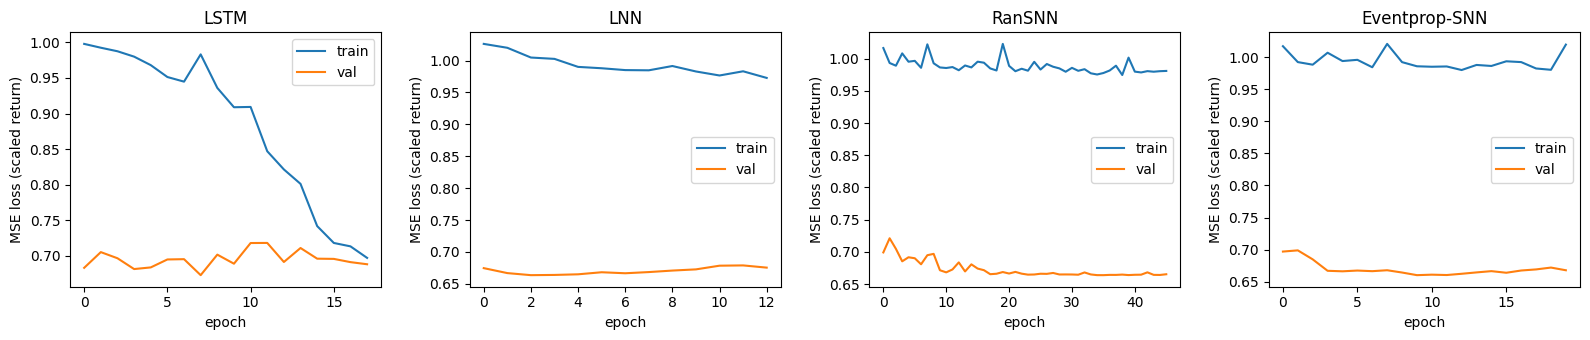

In [15]:
trainable_names = list(training_histories.keys())
n_models = len(trainable_names)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 3.5), squeeze=False)
axes = axes[0]

for ax, name in zip(axes, trainable_names):
    hist = training_histories[name]
    ax.plot(hist["train_loss"], label="train")
    ax.plot(hist["val_loss"], label="val")
    ax.set_title(name)
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE loss (scaled return)")
    ax.legend()

plt.tight_layout()
plt.show()


## Graph 2: Actual vs predicted price over the test period

Each deep/RandomForest model's seed-averaged prediction, plus Naive-Drift and
ARIMA, against the actual BSE Sensex close.


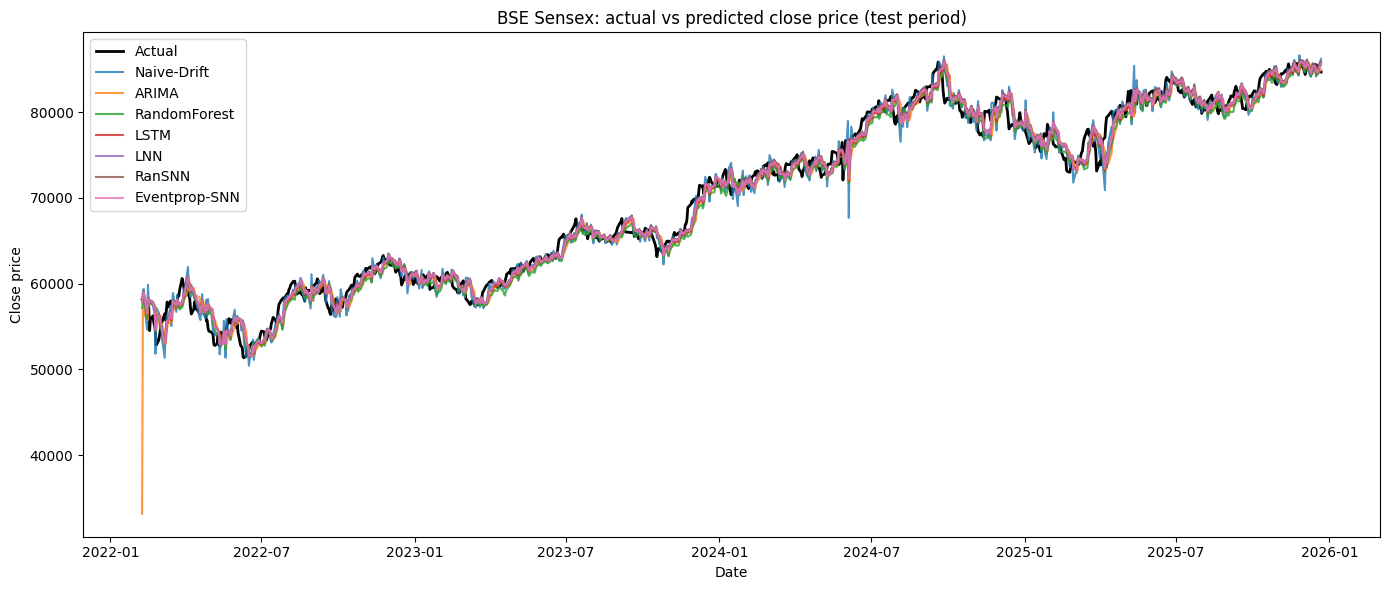

In [16]:
plt.figure(figsize=(14, 6))
plt.plot(test_dates, yprice_test, label="Actual", color="black", linewidth=2)

for name, preds in all_test_predictions.items():
    if name == "Naive":
        continue  # persistence is visually redundant with actual (near-identical, clutters the plot)
    mean_pred = preds.mean(axis=0)
    plt.plot(test_dates, mean_pred, label=name, alpha=0.8)

plt.title("BSE Sensex: actual vs predicted close price (test period)")
plt.xlabel("Date")
plt.ylabel("Close price")
plt.legend()
plt.tight_layout()
plt.show()


## Graph 3: MAPE and MDA comparison (bar charts with std error bars)

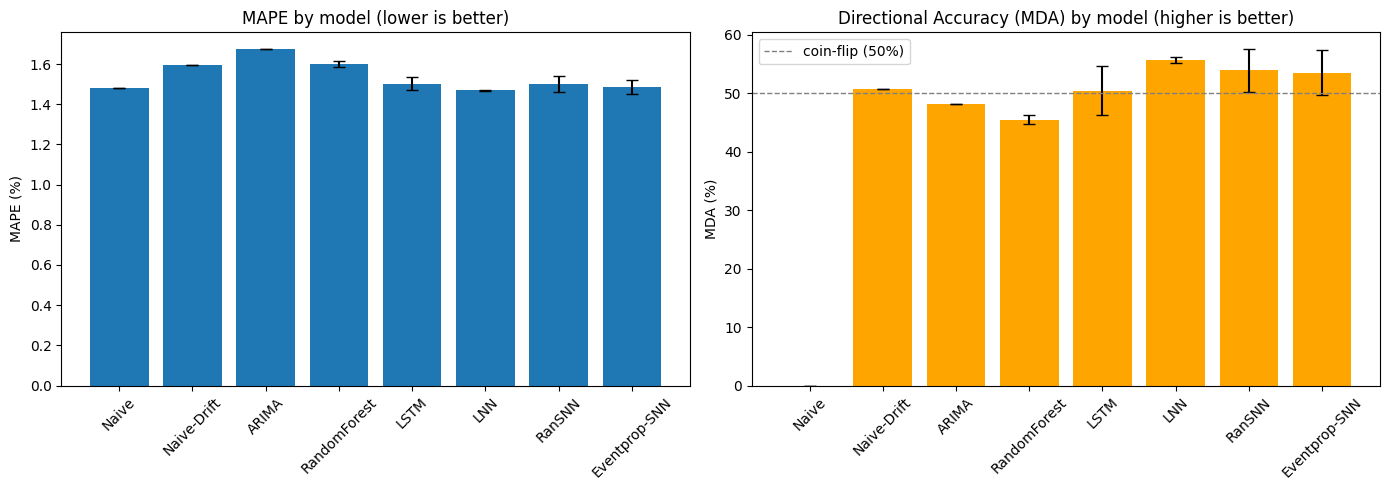

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results_df.index, results_df["MAPE"], yerr=results_std_df["MAPE"], capsize=4)
axes[0].set_title("MAPE by model (lower is better)")
axes[0].set_ylabel("MAPE (%)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(results_df.index, results_df["MDA"], yerr=results_std_df["MDA"], capsize=4, color="orange")
axes[1].axhline(50, color="gray", linestyle="--", linewidth=1, label="coin-flip (50%)")
axes[1].set_title("Directional Accuracy (MDA) by model (higher is better)")
axes[1].set_ylabel("MDA (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()


## Wilcoxon + Diebold-Mariano tests (each model's seed-averaged prediction vs Naive-Drift)

In [18]:
baseline_name = "Naive-Drift"
baseline_pred_mean = all_test_predictions[baseline_name].mean(axis=0)
baseline_errors = yprice_test - baseline_pred_mean

sig_results = {}
for name, preds in all_test_predictions.items():
    if name == baseline_name:
        continue
    model_pred_mean = preds.mean(axis=0)
    model_errors = yprice_test - model_pred_mean
    w_stat, w_p = wilcoxon_vs_baseline(model_errors, baseline_errors)
    dm_stat, dm_p = diebold_mariano(model_errors, baseline_errors, h=HORIZON)
    sig_results[name] = {
        "Wilcoxon_stat": w_stat, "Wilcoxon_p": w_p,
        "DM_stat": dm_stat, "DM_p": dm_p,
    }

pd.DataFrame(sig_results).T


,Wilcoxon_stat,Wilcoxon_p,DM_stat,DM_p
Naive,189744.0,2.441326e-05,-4.298977,0.000019
ARIMA,215251.0,2.300803e-01,0.921391,0.357081
RandomForest,218435.0,4.104117e-01,-1.171364,0.241747
LSTM,188225.0,1.082485e-05,-4.410239,0.000012
LNN,184247.0,1.110369e-06,-4.025218,0.000061
RanSNN,185213.0,1.968585e-06,-3.853086,0.000124
Eventprop-SNN,182708.0,4.344403e-07,-4.295259,0.000019


## TOPSIS ranking (equal + entropy weights)

Entropy-derived weights: {'MAE': 0.006772038732266595, 'MAPE': 0.007080856631217248, 'R2': 3.601875531405475e-05, 'MDA': 0.9861110858812021}


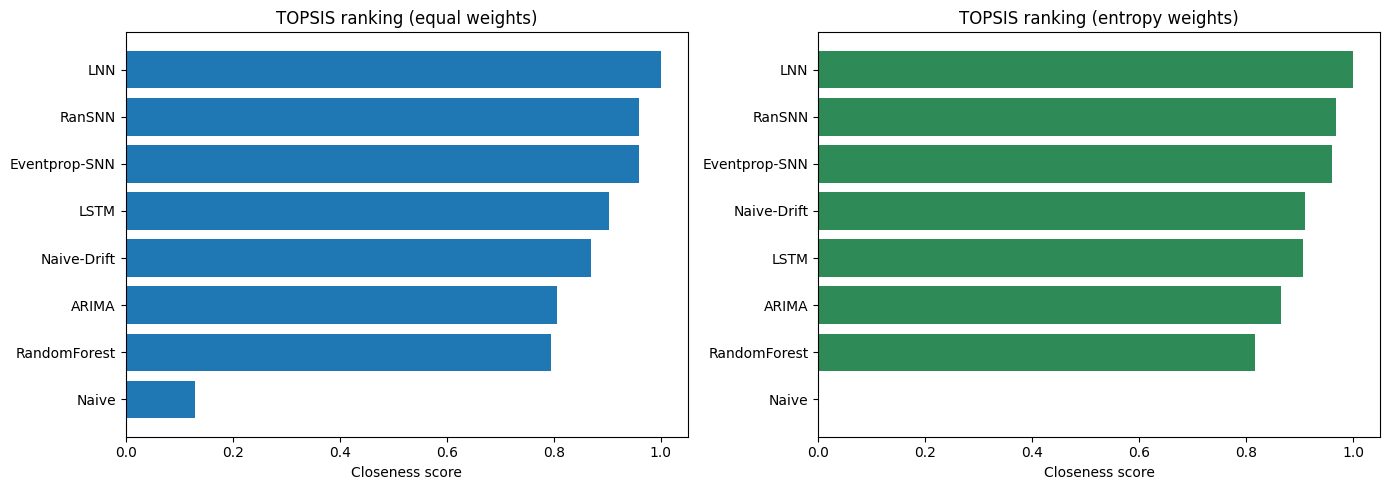

In [19]:
def topsis(df, weights=None, cost_cols=None):
    cost_cols = cost_cols or []
    data = df.copy().astype(float)
    norm = data / np.sqrt((data**2).sum())
    if weights is None:
        weights = {c: 1.0/len(data.columns) for c in data.columns}
    for c in data.columns:
        norm[c] = norm[c] * weights[c]
    ideal_best, ideal_worst = {}, {}
    for c in data.columns:
        if c in cost_cols:
            ideal_best[c] = norm[c].min(); ideal_worst[c] = norm[c].max()
        else:
            ideal_best[c] = norm[c].max(); ideal_worst[c] = norm[c].min()
    dist_best = np.sqrt(((norm - pd.Series(ideal_best))**2).sum(axis=1))
    dist_worst = np.sqrt(((norm - pd.Series(ideal_worst))**2).sum(axis=1))
    return (dist_worst / (dist_best + dist_worst)).sort_values(ascending=False)

def entropy_weights(df, cost_cols=None):
    cost_cols = cost_cols or []
    data = df.copy().astype(float)
    for c in cost_cols:
        data[c] = 1.0 / data[c]
    p = data / data.sum()
    p = p.replace(0, 1e-12)
    k = 1.0 / np.log(len(data))
    e = -k * (p * np.log(p)).sum()
    d = 1 - e
    return (d / d.sum()).to_dict()

COST_COLS = ["MAE", "MAPE"]
equal_ranking = topsis(results_df, weights=None, cost_cols=COST_COLS)
ent_w = entropy_weights(results_df, cost_cols=COST_COLS)
entropy_ranking = topsis(results_df, weights=ent_w, cost_cols=COST_COLS)

print("Entropy-derived weights:", ent_w)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(equal_ranking.index[::-1], equal_ranking.values[::-1])
axes[0].set_title("TOPSIS ranking (equal weights)")
axes[0].set_xlabel("Closeness score")

axes[1].barh(entropy_ranking.index[::-1], entropy_ranking.values[::-1], color="seagreen")
axes[1].set_title("TOPSIS ranking (entropy weights)")
axes[1].set_xlabel("Closeness score")

plt.tight_layout()
plt.show()


## Trading simulation (Sharpe, cumulative return, max drawdown vs buy-and-hold)

Run once per seed per model (not just on the seed-averaged prediction), so the
results table below reports mean +/- std across seeds - consistent with how
MAE/MAPE/R2/MDA are reported earlier in the notebook.


=== Trading results: mean across seeds (1 seed only for Naive/Naive-Drift/ARIMA) ===


,CumReturn,Sharpe,MaxDrawdown,BuyHoldCumReturn
Naive,0.000000,NaN,0.000000,5.81935
Naive-Drift,-0.161781,-0.003517,-0.415429,5.81935
ARIMA,-0.735680,-1.016922,-0.774054,5.81935
RandomForest,-0.801104,-1.308282,-0.903753,5.81935
LSTM,1.488482,0.284985,-0.633196,5.81935
LNN,4.498578,1.633324,-0.536703,5.81935
RanSNN,3.987921,1.185114,-0.614979,5.81935
Eventprop-SNN,3.447561,1.118798,-0.600349,5.81935



=== Trading results: std across seeds (0 for deterministic models) ===


,CumReturn,Sharpe,MaxDrawdown,BuyHoldCumReturn
Naive,0.000000,0.000000,0.000000,0.000000e+00
Naive-Drift,0.000000,0.000000,0.000000,0.000000e+00
ARIMA,0.000000,0.000000,0.000000,0.000000e+00
RandomForest,0.058592,0.256931,0.022661,8.881784e-16
LSTM,2.643925,1.187423,0.152000,8.881784e-16
LNN,1.109382,0.217570,0.014012,8.881784e-16
RanSNN,2.790072,1.087491,0.137474,8.881784e-16
Eventprop-SNN,2.383818,1.098892,0.125169,8.881784e-16


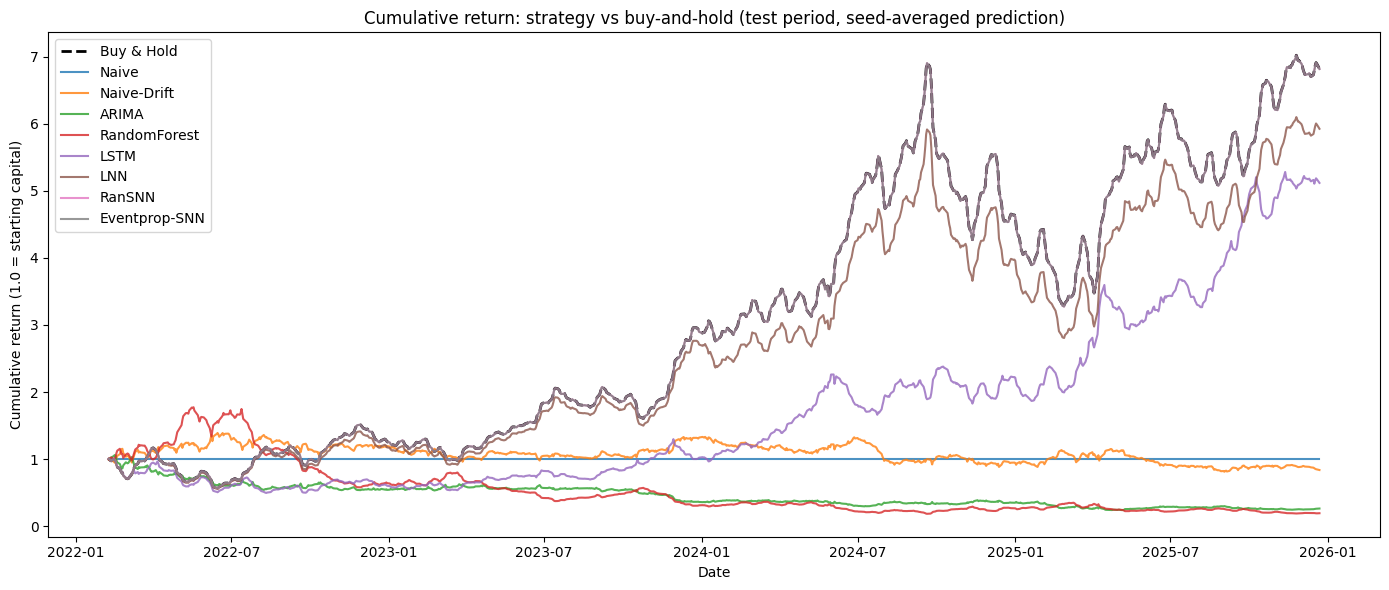

In [20]:
trading_results_per_seed = {}   # model name -> DataFrame [n_seeds, {CumReturn,Sharpe,MaxDrawdown,BuyHoldCumReturn}]
trading_results = {}            # model name -> mean across seeds
trading_results_std = {}        # model name -> std across seeds (0 for deterministic)
equity_curves = {}               # model name -> equity curve from the seed-averaged prediction (for plotting only)

for name, preds in all_test_predictions.items():
    # per-seed trading simulation: run once per seed, not just on the seed-averaged prediction
    seed_rows = []
    for seed_pred in preds:
        metrics_t, _, _ = trading_simulation(seed_pred, yprice_test, yprev_test)
        seed_rows.append(metrics_t)
    seed_df = pd.DataFrame(seed_rows)
    trading_results_per_seed[name] = seed_df
    trading_results[name] = seed_df.mean().to_dict()
    trading_results_std[name] = seed_df.std(ddof=0).fillna(0.0).to_dict()

    # seed-averaged prediction still used for the plotted equity curve (single readable line per model)
    mean_pred = preds.mean(axis=0)
    _, cum_strategy, cum_buyhold = trading_simulation(mean_pred, yprice_test, yprev_test)
    equity_curves[name] = cum_strategy

trading_results_df = pd.DataFrame(trading_results).T[["CumReturn", "Sharpe", "MaxDrawdown", "BuyHoldCumReturn"]]
trading_results_std_df = pd.DataFrame(trading_results_std).T[["CumReturn", "Sharpe", "MaxDrawdown", "BuyHoldCumReturn"]]

print("=== Trading results: mean across seeds (1 seed only for Naive/Naive-Drift/ARIMA) ===")
display(trading_results_df)
print("\n=== Trading results: std across seeds (0 for deterministic models) ===")
display(trading_results_std_df)

plt.figure(figsize=(14, 6))
plt.plot(test_dates, cum_buyhold, label="Buy & Hold", color="black", linewidth=2, linestyle="--")
for name, curve in equity_curves.items():
    plt.plot(test_dates, curve, label=name, alpha=0.8)
plt.title("Cumulative return: strategy vs buy-and-hold (test period, seed-averaged prediction)")
plt.xlabel("Date")
plt.ylabel("Cumulative return (1.0 = starting capital)")
plt.legend()
plt.tight_layout()
plt.show()


## Notes

- Single fixed 70/15/15 split, not walk-forward - report accordingly in the paper.
- All line plots use each model's **seed-averaged** prediction (mean across the 10
  seeds) for a single clean line per model; per-seed spread for MAE/MAPE/R2/MDA is
  in `per_seed_all[...]`, and per-seed spread for the trading metrics is in
  `trading_results_per_seed[...]` (see the trading simulation cell).
- Eventprop-SNN honesty note from v3 still applies - re-read before writing methods.
- FLANN has been removed (v5) - its tanh output activation bounded predictions to
  (-1, 1) against standardized-return targets that routinely exceed that range,
  which is a capacity bottleneck rather than a faithful architectural constraint.
- **5-day horizon caveat:** the trading simulation takes a fresh 5-day-ahead
  position every trading day, so consecutive rows' 5-day return windows overlap
  by 4 days - more overlap than the 3-day version had. Treat
  CumReturn/Sharpe/MaxDrawdown as "always holding a rolling 5-day view," not as
  a clean non-overlapping backtest - don't report the equity curve as if each
  5-day bet is independent.
- ARIMA now forecasts `steps=HORIZON` and keeps the last step, walking the fitted
  model forward one real observed close at a time - this replaces the 1-day
  version's `steps=1` shortcut, which only happened to line up because
  `HORIZON` was 1 there.
